In [67]:
# %pip install --user pandas openpyxl scikit-learn matplotlib seaborn numpy

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import seaborn as sns
import numpy as np

In [4]:
data = pd.read_excel('C:\\Users\\Admin\\Desktop\\Automation\\TATA\\Task-1\\TATA_GENAI_DATA_ANALYSIS\\Task_1\\Delinquency_prediction_dataset.xlsx', engine='openpyxl')
data.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [5]:
data.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    str    
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    str    
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    str    
 12  Location              500 non-null    str    
 13  Month_1               500 non-null    str    
 14  Month_2               500 non-null    str    
 15  Month_3               500 non-null

In [7]:
data.isnull().sum()

Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64

In [8]:
column_id = data['Customer_ID']

In [9]:
print(column_id)

0      CUST0001
1      CUST0002
2      CUST0003
3      CUST0004
4      CUST0005
         ...   
495    CUST0496
496    CUST0497
497    CUST0498
498    CUST0499
499    CUST0500
Name: Customer_ID, Length: 500, dtype: str


In [10]:
data.drop(columns=['Customer_ID'], inplace=True)
data.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [11]:
data['Credit_Card_Type'].unique()

<StringArray>
['Student', 'Standard', 'Platinum', 'Gold', 'Business']
Length: 5, dtype: str

In [12]:
data['Credit_Card_Type'].isnull().sum()

np.int64(0)

In [13]:
credit_encoded_data = pd.get_dummies(data, columns=['Credit_Card_Type'], dtype = int)
credit_encoded_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        500 non-null    int64  
 1   Income                     461 non-null    float64
 2   Credit_Score               498 non-null    float64
 3   Credit_Utilization         500 non-null    float64
 4   Missed_Payments            500 non-null    int64  
 5   Delinquent_Account         500 non-null    int64  
 6   Loan_Balance               471 non-null    float64
 7   Debt_to_Income_Ratio       500 non-null    float64
 8   Employment_Status          500 non-null    str    
 9   Account_Tenure             500 non-null    int64  
 10  Location                   500 non-null    str    
 11  Month_1                    500 non-null    str    
 12  Month_2                    500 non-null    str    
 13  Month_3                    500 non-null    str    
 14  Month

In [14]:
credit_encoded_data.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,...,Month_2,Month_3,Month_4,Month_5,Month_6,Credit_Card_Type_Business,Credit_Card_Type_Gold,Credit_Card_Type_Platinum,Credit_Card_Type_Standard,Credit_Card_Type_Student
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,...,Late,Missed,Late,Missed,Late,0,0,0,0,1
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,...,Missed,Late,Missed,On-time,On-time,0,0,0,1,0
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,...,Late,Late,On-time,Missed,Late,0,0,1,0,0
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,...,Missed,Late,Missed,Late,Late,0,0,1,0,0
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,...,On-time,Missed,Late,Late,Late,0,0,0,1,0


In [15]:
credit_encoded_data['Employment_Status'].unique()

<StringArray>
['EMP', 'Self-employed', 'Unemployed', 'employed', 'Employed', 'retired']
Length: 6, dtype: str

In [16]:
credit_encoded_data['Location'].unique()

<StringArray>
['Los Angeles', 'Phoenix', 'Chicago', 'New York', 'Houston']
Length: 5, dtype: str

In [17]:
credit_encoded_data['Month_2'].unique()

<StringArray>
['Late', 'Missed', 'On-time']
Length: 3, dtype: str

In [18]:
month_map = {
    'Late' : 0,
    'Missed' : 1,
    'On-time' : 2
}
credit_encoded_data['Month_1'] = credit_encoded_data['Month_1'].map(month_map)
credit_encoded_data['Month_2'] = credit_encoded_data['Month_2'].map(month_map)
credit_encoded_data['Month_3'] = credit_encoded_data['Month_3'].map(month_map)
credit_encoded_data['Month_4'] = credit_encoded_data['Month_4'].map(month_map)
credit_encoded_data['Month_5'] = credit_encoded_data['Month_5'].map(month_map)
credit_encoded_data['Month_6'] = credit_encoded_data['Month_6'].map(month_map)


In [19]:
credit_encoded_data[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']].head()

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,0,0,1,0,1,0
1,1,1,0,1,2,2
2,1,0,0,2,1,0
3,0,1,0,1,0,0
4,1,2,1,0,0,0


In [20]:
encoded_data = pd.get_dummies(credit_encoded_data, columns=['Employment_Status', 'Location'], dtype = int)
encoded_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              500 non-null    int64  
 1   Income                           461 non-null    float64
 2   Credit_Score                     498 non-null    float64
 3   Credit_Utilization               500 non-null    float64
 4   Missed_Payments                  500 non-null    int64  
 5   Delinquent_Account               500 non-null    int64  
 6   Loan_Balance                     471 non-null    float64
 7   Debt_to_Income_Ratio             500 non-null    float64
 8   Account_Tenure                   500 non-null    int64  
 9   Month_1                          500 non-null    int64  
 10  Month_2                          500 non-null    int64  
 11  Month_3                          500 non-null    int64  
 12  Month_4                          

In [21]:
encoded_data.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,Month_1,...,Employment_Status_Employed,Employment_Status_Self-employed,Employment_Status_Unemployed,Employment_Status_employed,Employment_Status_retired,Location_Chicago,Location_Houston,Location_Los Angeles,Location_New York,Location_Phoenix
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,18,0,...,0,0,0,0,0,0,0,1,0,0
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,0,1,...,0,1,0,0,0,0,0,0,0,1
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,1,1,...,0,1,0,0,0,1,0,0,0,0
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,15,0,...,0,0,1,0,0,0,0,0,0,1
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,11,1,...,0,1,0,0,0,0,0,0,0,1


In [24]:
encoded_data['Income'].describe()

count       461.000000
mean     108379.893709
std       53662.723741
min       15404.000000
25%       62295.000000
50%      107658.000000
75%      155734.000000
max      199943.000000
Name: Income, dtype: float64

In [25]:
encoded_data['Loan_Balance'].describe()

count      471.000000
mean     48654.428875
std      29395.537273
min        612.000000
25%      23716.500000
50%      45776.000000
75%      75546.500000
max      99620.000000
Name: Loan_Balance, dtype: float64

In [27]:
LB=encoded_data.loc[encoded_data['Loan_Balance'].isnull(), ['Income', 'Loan_Balance', 'Delinquent_Account']]
LB

,Income,Loan_Balance,Delinquent_Account
8,66991.0,NaN,1
23,108468.0,NaN,1
25,193998.0,NaN,0
28,86726.0,NaN,0
45,59238.0,NaN,1
51,109074.0,NaN,0
52,185806.0,NaN,0
102,163216.0,NaN,1
104,178165.0,NaN,0
115,121884.0,NaN,0


In [29]:
LB['Delinquent_Account'].value_counts()

Delinquent_Account
0    22
1     7
Name: count, dtype: int64

In [30]:
# encoded_data.to_csv('encoded_data.csv', index=False)

In [31]:
numeric_cols = encoded_data.select_dtypes(include="number").columns

scaler = StandardScaler()
scaled = scaler.fit_transform(encoded_data[numeric_cols])

imputer = KNNImputer(n_neighbors=5)
scaled_imputed = imputer.fit_transform(scaled)

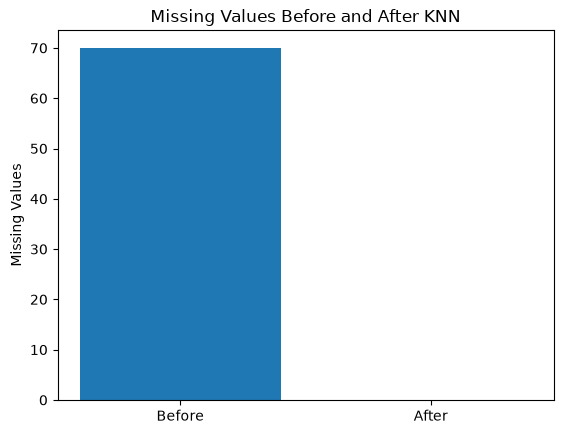

In [33]:
imputed_data = pd.DataFrame(
    scaler.inverse_transform(scaled_imputed),
    columns=numeric_cols,
    index=encoded_data.index
)

missing_before = encoded_data.isna().sum().sum()
missing_after = imputed_data.isna().sum().sum()

plt.bar(["Before","After"], [missing_before, missing_after])
plt.ylabel("Missing Values")
plt.title("Missing Values Before and After KNN")
plt.show()

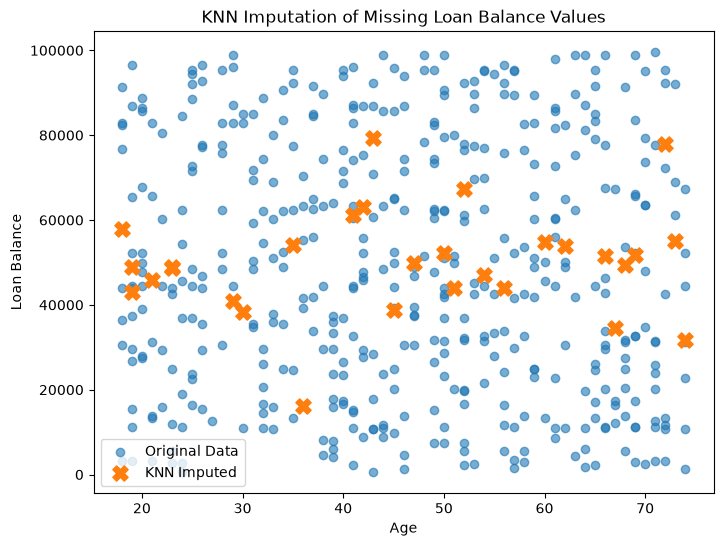

In [38]:
missing_rows = encoded_data["Loan_Balance"].isna()

plt.figure(figsize=(8,6))

# Original (non-missing)
plt.scatter(
    encoded_data.loc[~missing_rows, "Age"],
    encoded_data.loc[~missing_rows, "Loan_Balance"],
    label="Original Data",
    alpha=0.6
)

# KNN Imputed values
plt.scatter(
    imputed_data.loc[missing_rows, "Age"],
    imputed_data.loc[missing_rows, "Loan_Balance"],
    marker="X",
    s=120,
    label="KNN Imputed"
)

plt.xlabel("Age")
plt.ylabel("Loan Balance")
plt.title("KNN Imputation of Missing Loan Balance Values")
plt.legend()
plt.show()

In [40]:
imputed_data.isna().sum().sum()

np.int64(0)

In [57]:
imputed_data.columns

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Account_Tenure', 'Month_1', 'Month_2',
       'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Credit_Card_Type_Business',
       'Credit_Card_Type_Gold', 'Credit_Card_Type_Platinum',
       'Credit_Card_Type_Standard', 'Credit_Card_Type_Student',
       'Employment_Status_EMP', 'Employment_Status_Employed',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Employment_Status_employed', 'Employment_Status_retired',
       'Location_Chicago', 'Location_Houston', 'Location_Los Angeles',
       'Location_New York', 'Location_Phoenix'],
      dtype='str')

In [68]:
corr_matrix = imputed_data[['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Account_Tenure']].corr(numeric_only=True)
corr_matrix

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
Age,1.000000,0.011452,-0.032373,0.015811,-0.023511,0.022508,-0.045479,-0.007883,0.016942
Income,0.011452,1.000000,0.080455,0.042155,-0.012276,0.052564,-0.042060,-0.062616,-0.003550
Credit_Score,-0.032373,0.080455,1.000000,-0.020651,-0.012851,0.034242,-0.027667,-0.005019,-0.037815
Credit_Utilization,0.015811,0.042155,-0.020651,1.000000,0.019666,0.034224,-0.052831,-0.064661,0.065264
Missed_Payments,-0.023511,-0.012276,-0.012851,0.019666,1.000000,-0.026478,-0.016733,0.000148,-0.097345
Delinquent_Account,0.022508,0.052564,0.034242,0.034224,-0.026478,1.000000,-0.005079,0.034386,-0.039829
Loan_Balance,-0.045479,-0.042060,-0.027667,-0.052831,-0.016733,-0.005079,1.000000,0.055384,0.055238
Debt_to_Income_Ratio,-0.007883,-0.062616,-0.005019,-0.064661,0.000148,0.034386,0.055384,1.000000,0.026144
Account_Tenure,0.016942,-0.003550,-0.037815,0.065264,-0.097345,-0.039829,0.055238,0.026144,1.000000


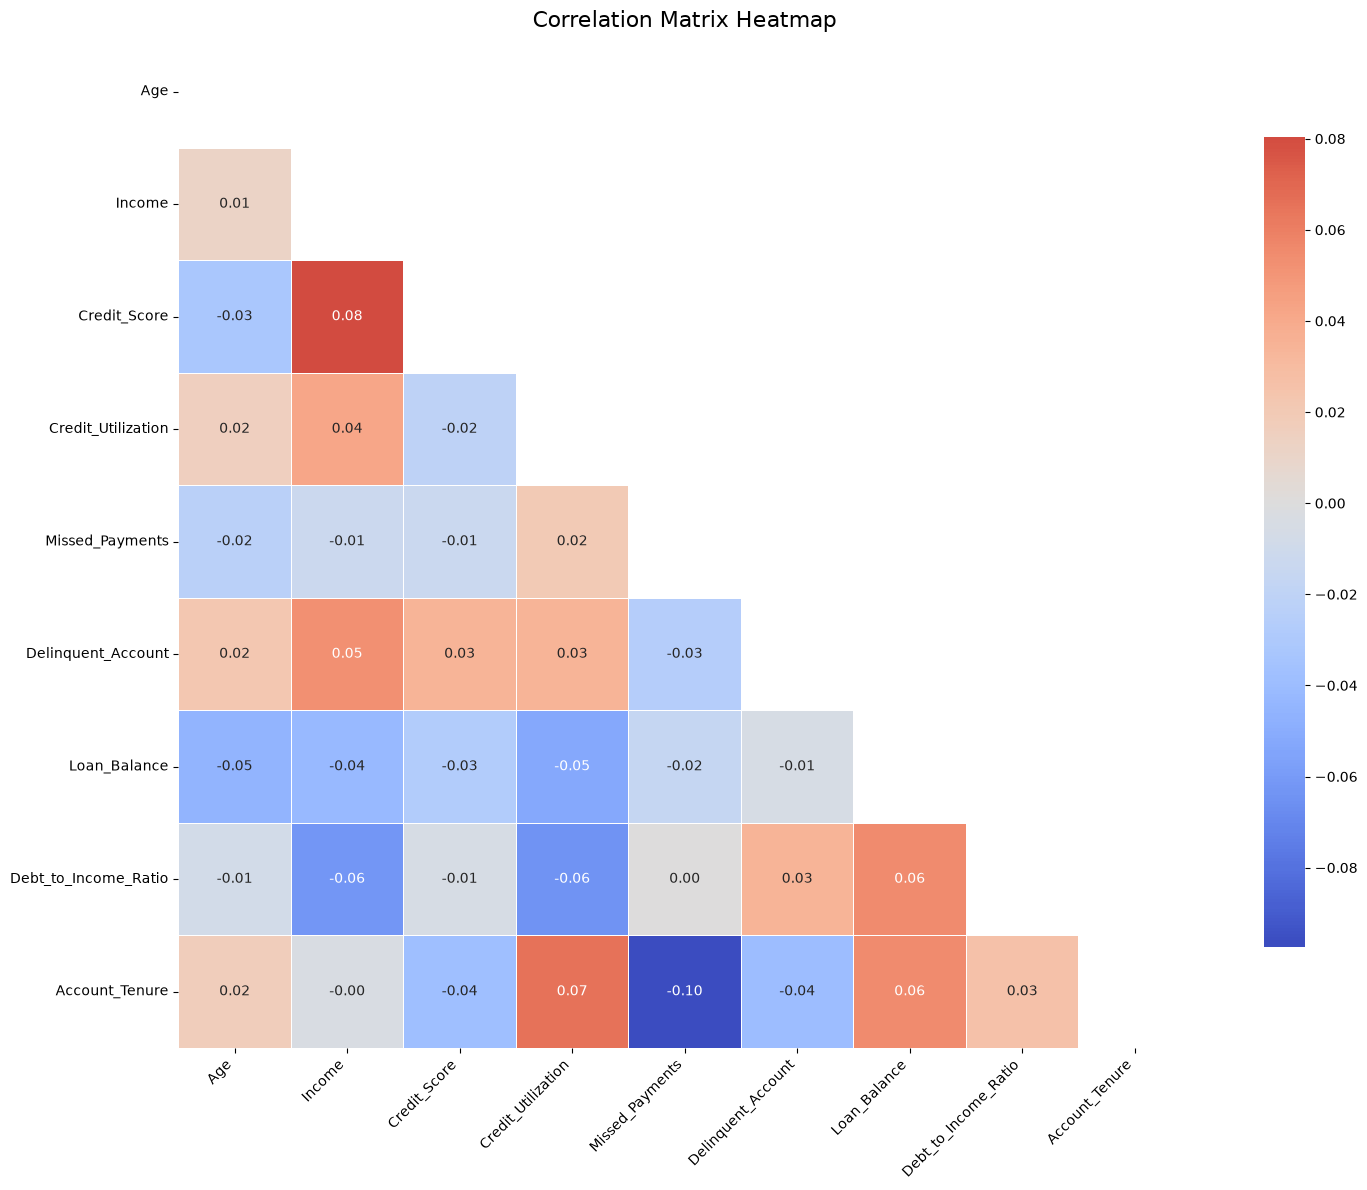

In [69]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()